# 11 Baseline N1: Bibliographic-Coupling Neighborhood Baseline

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '11_baseline_n1_bibliographic_coupling'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
BC_DATA_DIR = PROJECT_ROOT / 'outputs' / '04_bibliographic_coupling_network' / 'data'

In [2]:
def standardize_edges(edges):
    out = edges[['citing_paper_id', 'cited_paper_id']].copy()
    out['citing_paper_id'] = out['citing_paper_id'].astype(str)
    out['cited_paper_id'] = out['cited_paper_id'].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
    cs_papers = pd.read_pickle(PROCESSED_DIR / 'cs_papers_final.pkl')
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl'))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl'))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl'))
    papers['id'] = papers['id'].astype(str)
    cs_papers['id'] = cs_papers['id'].astype(str)
    return (papers, cs_papers, all_edges, all_to_cs, cs_to_cs)

def known_cs(cs_papers):
    return cs_papers[cs_papers['first_last_cat'].isin(GENDER_CATEGORIES)].copy()

def aggregate_oe(observed, expected, baseline, citation_slice):
    rows = []
    for g in GENDER_CATEGORIES:
        o = float(observed.get(g, 0.0))
        e = float(expected.get(g, 0.0))
        oe = o / e if e > 0 else np.nan
        rows.append({'gender_cat': g, 'observed_citations': o, 'expected_citations': e, 'oe_ratio': oe, 'pct_diff_from_expected': (oe - 1.0) * 100 if pd.notna(oe) else np.nan, 'baseline': baseline, 'citation_slice': citation_slice})
    return pd.DataFrame(rows)

def prepare_cited_edges(edges, cs_known, extra_cols):
    meta_cols = ['id', 'first_last_cat'] + list(extra_cols)
    meta = cs_known[meta_cols].drop_duplicates('id').rename(columns={'id': 'cited_paper_id', 'first_last_cat': 'cited_gender'})
    return edges.merge(meta, on='cited_paper_id', how='inner')

In [3]:
def standardize_undirected_network(net):
    out = net[['paper_i', 'paper_j', 'shared_references']].rename(columns={'shared_references': 'weight'}).copy()
    out['paper_i'] = out['paper_i'].astype(str)
    out['paper_j'] = out['paper_j'].astype(str)
    out['weight'] = pd.to_numeric(out['weight'], errors='coerce')
    return out[out['weight'].gt(0) & out['paper_i'].ne(out['paper_j'])].drop_duplicates(['paper_i', 'paper_j']).copy()

def paper_observed(cs_known, edges, outcome):
    counts = edges['cited_paper_id'].value_counts().rename(outcome)
    out = cs_known[['id', 'first_last_cat', 'year', 'decade']].rename(columns={'id': 'paper_id', 'first_last_cat': 'gender_cat'}).copy()
    out[outcome] = out['paper_id'].map(counts).fillna(0).astype(float)
    return out

def network_neighborhood_expected(paper_df, net, outcome_col, representation, citation_slice):
    ymap = paper_df.set_index('paper_id')[outcome_col]
    known = set(paper_df['paper_id'])
    fwd = net.rename(columns={'paper_i': 'paper_id', 'paper_j': 'neighbor_id'})
    rev = net.rename(columns={'paper_j': 'paper_id', 'paper_i': 'neighbor_id'})
    d = pd.concat([fwd, rev], ignore_index=True)
    d = d[d['paper_id'].isin(known) & d['neighbor_id'].isin(known)].copy()
    d['neighbor_y'] = d['neighbor_id'].map(ymap)
    d['weighted_y'] = d['weight'] * d['neighbor_y']
    g = d.groupby('paper_id', sort=False).agg(weight_sum=('weight', 'sum'), weighted_y_sum=('weighted_y', 'sum'), n_valid_neighbors=('neighbor_id', 'nunique'))
    g['expected_raw'] = g['weighted_y_sum'] / g['weight_sum']
    covered = paper_df.merge(g[['expected_raw', 'n_valid_neighbors', 'weight_sum']], left_on='paper_id', right_index=True, how='inner')
    covered = covered[np.isfinite(covered['expected_raw']) & covered['weight_sum'].gt(0)].copy()
    scale = covered[outcome_col].sum() / covered['expected_raw'].sum()
    covered['expected_calibrated'] = covered['expected_raw'] * scale
    result = covered.groupby('gender_cat').agg(n_papers=('paper_id', 'nunique'), observed_citations=(outcome_col, 'sum'), expected_citations=('expected_calibrated', 'sum')).reindex(GENDER_CATEGORIES).reset_index()
    result['oe_ratio'] = result['observed_citations'] / result['expected_citations'].replace(0, np.nan)
    result['pct_diff_from_expected'] = (result['oe_ratio'] - 1) * 100
    result['baseline'] = representation
    result['citation_slice'] = citation_slice
    result['calibration_factor'] = scale
    result['coverage_papers'] = len(covered)
    result['coverage_share'] = len(covered) / len(paper_df)
    return (result, covered)

## 1. Load final data and final bibliographic-coupling network

In [4]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
cs_known = known_cs(cs_papers)
bib_raw = pd.read_pickle(BC_DATA_DIR / 'net_bib_coupling_topk.pkl')
bib = standardize_undirected_network(bib_raw)
print('Known-gender CS papers:', cs_known.shape)
print('Bibliographic-coupling edges:', bib.shape)

Known-gender CS papers: (1081363, 29)
Bibliographic-coupling edges: (3934046, 3)


## 2. N1 All→CS and CS→CS

In [5]:
p_all = paper_observed(cs_known, edges_all_to_cs, 'observed')
p_cs = paper_observed(cs_known, edges_cs_to_cs, 'observed')
n1_all, n1_all_papers = network_neighborhood_expected(p_all, bib, 'observed', 'N1_bibliographic_coupling', 'All→CS')
n1_cs, n1_cs_papers = network_neighborhood_expected(p_cs, bib, 'observed', 'N1_bibliographic_coupling', 'CS→CS')
n1_results = pd.concat([n1_all, n1_cs], ignore_index=True)
n1_results

,gender_cat,n_papers,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice,calibration_factor,coverage_papers,coverage_share
0,MM,256410,"3,363,973.0000","3,203,882.0370",1.0500,4.9968,N1_bibliographic_coupling,All→CS,0.8968,348132,0.3219
1,MW,31795,"327,653.0000","372,077.0184",0.8806,-11.9395,N1_bibliographic_coupling,All→CS,0.8968,348132,0.3219
2,WM,45395,"412,980.0000","499,216.3232",0.8273,-17.2743,N1_bibliographic_coupling,All→CS,0.8968,348132,0.3219
3,WW,14532,"116,824.0000","146,254.6215",0.7988,-20.1229,N1_bibliographic_coupling,All→CS,0.8968,348132,0.3219
4,MM,256410,"2,799,203.0000","2,673,235.7082",1.0471,4.7122,N1_bibliographic_coupling,CS→CS,0.8925,348132,0.3219
5,MW,31795,"279,978.0000","313,991.8636",0.8917,-10.8327,N1_bibliographic_coupling,CS→CS,0.8925,348132,0.3219
6,WM,45395,"351,839.0000","418,640.8273",0.8404,-15.9568,N1_bibliographic_coupling,CS→CS,0.8925,348132,0.3219
7,WW,14532,"97,949.0000","123,100.6009",0.7957,-20.4317,N1_bibliographic_coupling,CS→CS,0.8925,348132,0.3219


## 3. Visualize

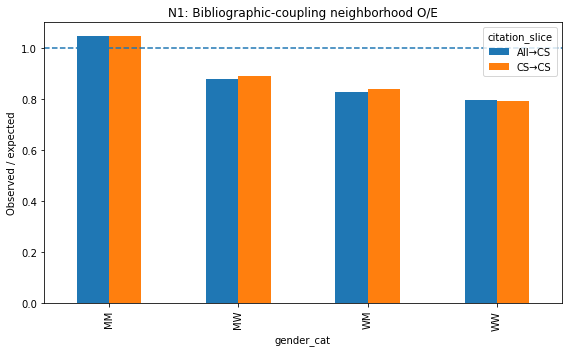

In [6]:
plot = n1_results.pivot(index='gender_cat', columns='citation_slice', values='oe_ratio').reindex(GENDER_CATEGORIES)
ax = plot.plot(kind='bar', figsize=(8, 5))
ax.axhline(1.0, linestyle='--')
ax.set_ylabel('Observed / expected')
ax.set_title('N1: Bibliographic-coupling neighborhood O/E')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_n1_bibliographic_coupling.png', dpi=300)
plt.show()

## 4. Save outputs

In [7]:
n1_results.to_csv(TABLE_DIR / 'n1_bibliographic_coupling_oe_by_gender.csv', index=False)
pd.concat([n1_all_papers.assign(citation_slice='All→CS'), n1_cs_papers.assign(citation_slice='CS→CS')]).to_pickle(DATA_OUTPUT_DIR / 'n1_bibliographic_coupling_paper_level.pkl')
print('Saved:', NOTEBOOK_OUTPUT_DIR)

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\11_baseline_n1_bibliographic_coupling
